# ****Required Libraries****

In [73]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import fcluster
from sklearn.decomposition import PCA

# ****Load the transaction data and inspect shape, data types, null values, duplicates, cancellations, negative quantities, and invalid prices****

In [4]:
df = pd.read_excel('Online Retail.xlsx')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [5]:
df.shape

(541909, 8)

In [6]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df['CustomerID'].value_counts(dropna=False)

CustomerID
NaN        135080
17841.0      7983
14911.0      5903
14096.0      5128
12748.0      4642
            ...  
18184.0         1
13256.0         1
13017.0         1
18174.0         1
15195.0         1
Name: count, Length: 4373, dtype: int64

In [10]:
df = df.dropna(subset=['CustomerID'])

In [11]:
df['CustomerID'].value_counts()

CustomerID
17841.0    7983
14911.0    5903
14096.0    5128
12748.0    4642
14606.0    2782
           ... 
18184.0       1
13256.0       1
13017.0       1
18174.0       1
15195.0       1
Name: count, Length: 4372, dtype: int64

In [12]:
df.duplicated().sum()

np.int64(5225)

In [13]:
df = df.drop_duplicates()

In [14]:
df["InvoiceNo"].astype(str).str.extract(r"(^\D+)")[0].value_counts(dropna=False)

0
NaN    392732
C        8872
Name: count, dtype: int64

In [15]:
df = df[df["InvoiceNo"].astype(str).str.isnumeric()]

In [16]:
df["InvoiceNo"].astype(str).str.extract(r"(^\D+)")[0].value_counts(dropna=False)

0
NaN    392732
Name: count, dtype: int64

In [17]:
df[df['Quantity'] < 1]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [18]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [19]:
df = df[df['UnitPrice'] > 0]

# ****Create TotalAmount and customer-level RFM features: Recency, Frequency, and Monetary Value. Add average order value and unique products purchased.****

In [20]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df = df.drop(columns=['Quantity', 'UnitPrice'])

In [21]:
Snapshot_Date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
CustomerData = df.groupby("CustomerID").agg({"InvoiceDate": lambda x: (Snapshot_Date - x.max()).days,"InvoiceNo": "nunique","TotalAmount": "sum"})
CustomerData.columns = ["Recency", "Frequency", "Monetary"]
CustomerData = CustomerData.reset_index()

In [22]:
CustomerData["AverageOrderValue"] = CustomerData["Monetary"] / CustomerData["Frequency"]

In [23]:
UniqueProducts = (df.groupby("CustomerID")["StockCode"].nunique().reset_index(name="UniqueProducts"))
UniqueProducts
CustomerData = CustomerData.merge(UniqueProducts, on='CustomerID', how="left")

In [24]:
CustomerData

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts
0,12346.0,326,1,77183.60,77183.600000,1
1,12347.0,2,7,4310.00,615.714286,103
2,12348.0,75,4,1797.24,449.310000,22
3,12349.0,19,1,1757.55,1757.550000,73
4,12350.0,310,1,334.40,334.400000,17
...,...,...,...,...,...,...
4333,18280.0,278,1,180.60,180.600000,10
4334,18281.0,181,1,80.82,80.820000,7
4335,18282.0,8,2,178.05,89.025000,12
4336,18283.0,4,16,2045.53,127.845625,263


# ****Visualize feature distributions and correlations. Apply suitable log transformation and StandardScaler or RobustScaler.****

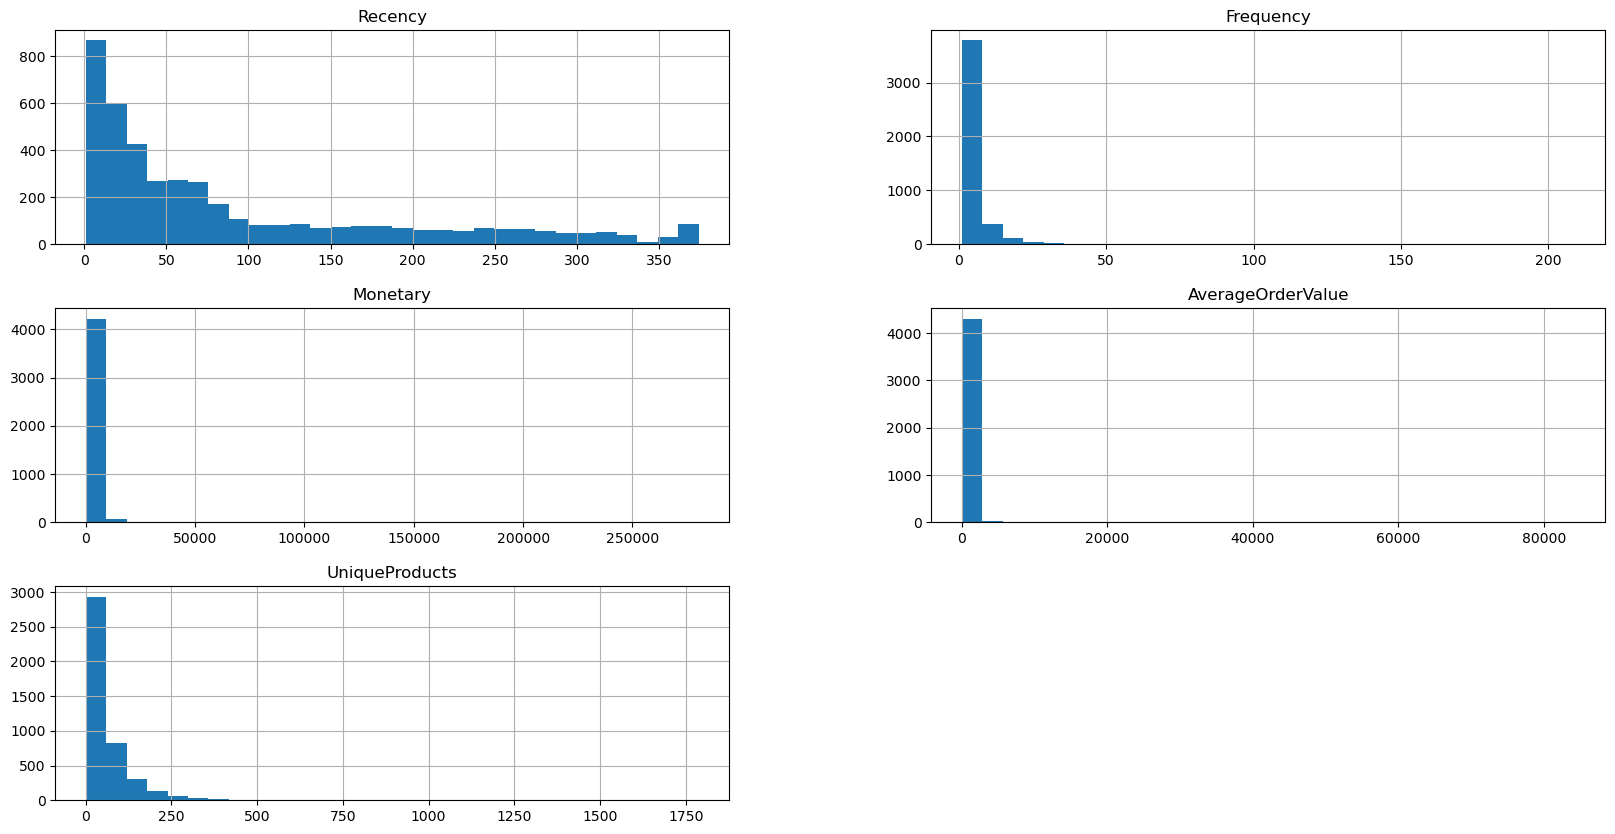

In [25]:
Features = ['Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'UniqueProducts']
CustomerData[Features].hist(figsize=(20, 10),bins=30)
plt.show()

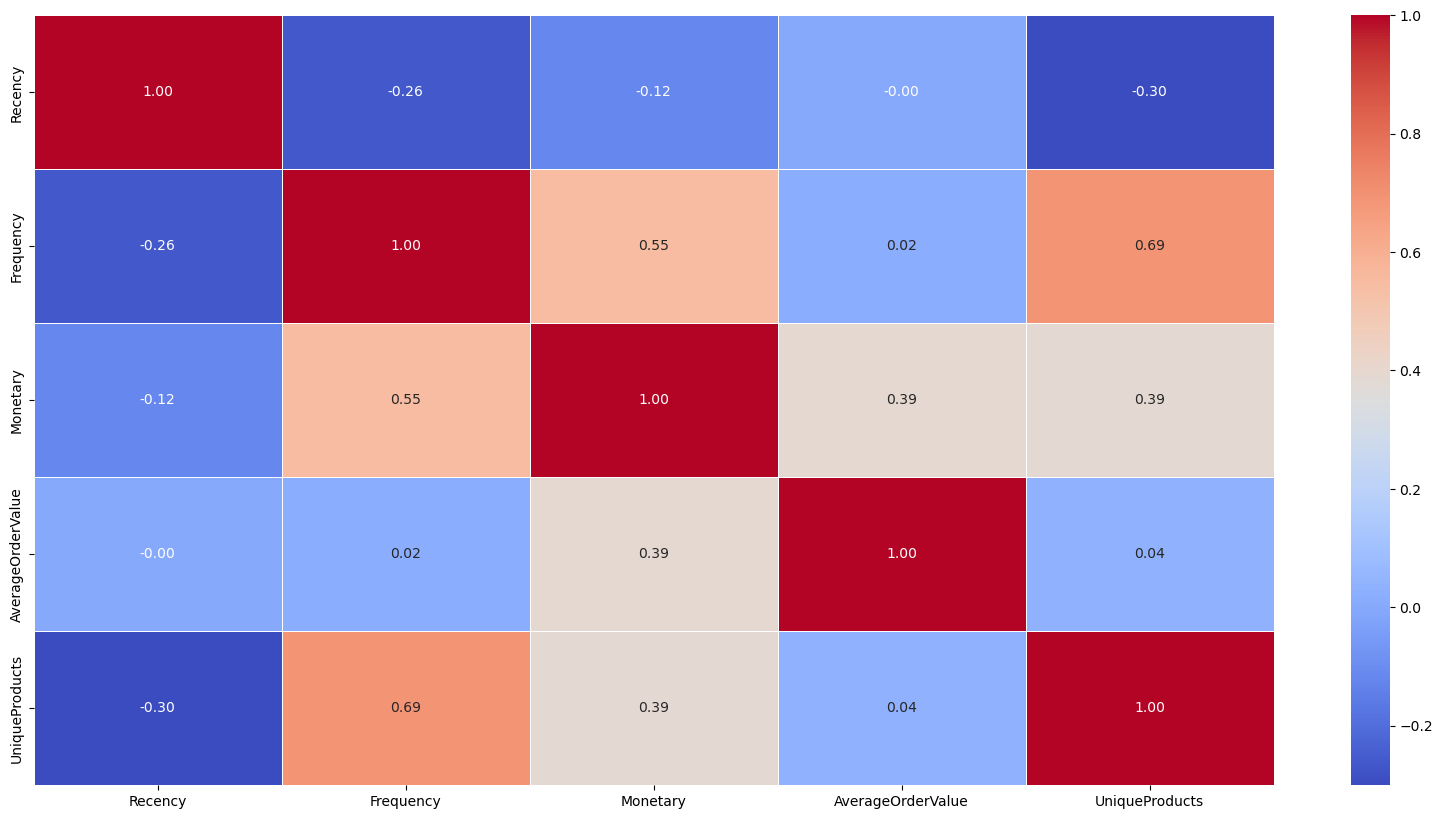

In [26]:
Correlation = CustomerData[Features].corr()
plt.figure(figsize=(20, 10))
sns.heatmap(Correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

In [27]:
CustomerData["Frequency"] = np.log1p(CustomerData["Frequency"])
CustomerData["Monetary"] = np.log1p(CustomerData["Monetary"])
CustomerData["AverageOrderValue"] = np.log1p(CustomerData["AverageOrderValue"])
CustomerData["UniqueProducts"] = np.log1p(CustomerData["UniqueProducts"])

In [28]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
CustomerData[Features] = scaler.fit_transform(CustomerData[Features])

# ****Train K-Means for k = 2 to 8. Use the elbow curve and silhouette score to select the best value of k.****

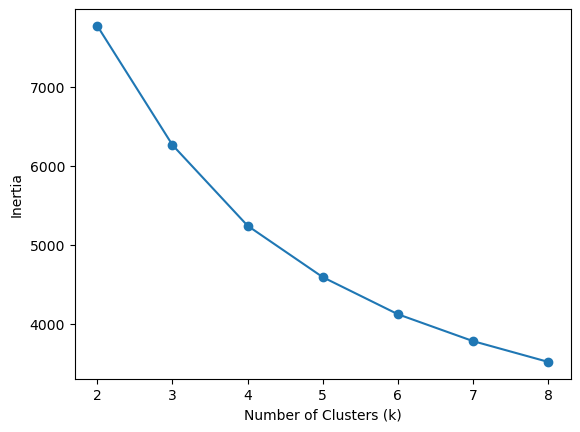

In [29]:
inertia = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(CustomerData[Features])
    inertia.append(model.inertia_)

plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [30]:
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(CustomerData[Features])
    score = silhouette_score(CustomerData[Features], labels)
    print(f"k={k}, Silhouette Score={score:.3f}")

k=2, Silhouette Score=0.327
k=3, Silhouette Score=0.273
k=4, Silhouette Score=0.263
k=5, Silhouette Score=0.263
k=6, Silhouette Score=0.244
k=7, Silhouette Score=0.233
k=8, Silhouette Score=0.232


In [31]:
kmeans2 = KMeans(n_clusters=2, random_state=42)
CustomerData["Cluster2"] = kmeans2.fit_predict(CustomerData[Features])

In [32]:
kmeans4 = KMeans(n_clusters=4, random_state=42)
CustomerData["Cluster4"] = kmeans4.fit_predict(CustomerData[Features])

# ****Profile K-Means clusters using cluster size, median RFM values, spending level, and purchase frequency.****

In [37]:
print('Cluster 2 Profile:')
Cluster2_Profile = CustomerData.groupby("Cluster2").agg({
    "CustomerID": "count",
    "Recency": "median",
    "Frequency": "median",
    "Monetary": "median",
    "AverageOrderValue": "median",
    "UniqueProducts": "median"
}).rename(columns={"CustomerID": "ClusterSize"})
Cluster2_Profile

Cluster 2 Profile:


,ClusterSize,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts
Cluster2,,,,,,
0,2059,0.612903,-0.369070,-0.481331,-0.473383,-0.492490
1,2279,-0.209677,0.464974,0.503441,0.272958,0.464025


In [38]:
print('Cluster 4 Profile:')
Cluster4_Profile = CustomerData.groupby("Cluster4").agg({
    "CustomerID": "count",
    "Recency": "median",
    "Frequency": "median",
    "Monetary": "median",
    "AverageOrderValue": "median",
    "UniqueProducts": "median"
}).rename(columns={"CustomerID": "ClusterSize"})
Cluster4_Profile

Cluster 4 Profile:


,ClusterSize,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts
Cluster4,,,,,,
0,760,0.060484,-0.36907,-0.762494,-0.941438,-0.721113
1,1068,-0.282258,1.00000,0.893234,0.400067,0.768018
2,1717,-0.056452,0.00000,0.070076,0.106494,0.085365
3,793,1.741935,-0.36907,-0.459389,-0.236905,-0.454972


In [40]:
CustomerData["SpendingLevel"] = pd.cut(CustomerData["Monetary"], bins=3, labels=["Low", "Medium", "High"])
print("Spending Level Distribution by Cluster2:")
print(pd.crosstab(CustomerData["Cluster2"], CustomerData["SpendingLevel"]))
print("Spending Level Distribution by Cluster4:")
print(pd.crosstab(CustomerData["Cluster4"], CustomerData["SpendingLevel"]))

Spending Level Distribution by Cluster2:
SpendingLevel  Low  Medium  High
Cluster2                        
0              586    1473     0
1                0    2122   157
Spending Level Distribution by Cluster4:
SpendingLevel  Low  Medium  High
Cluster4                        
0              380     380     0
1                0     911   157
2                0    1717     0
3              206     587     0


### ****Although K=2 achieved the highest Silhouette Score (0.327) but poor Inertia, it only separated customers into two groups. While K=4, with a Silhouette Score of 0.263 and better Inertia, produced four meaningful and actionable customer segments. These segments provide richer business insights and support targeted marketing and customer retention strategies. Therefore, K=4 was selected as the final model despite the slightly lower silhouette score.****

In [46]:
model_kmeans = kmeans4
CustomerData["Cluster4"] = model_kmeans.fit_predict(CustomerData[Features])

# ****Apply Hierarchical Clustering. Compare ward, complete, and average linkage; create and interpret a dendrogram****

In [ ]:
linkage_methods = ['ward', 'complete', 'average']
linkage_results = {}
for method in linkage_methods:
    linkage_results[method] = linkage(CustomerData[Features], method=method)

In [48]:
print("Linkage Method Comparison:")
print(f"Ward Linkage - Last 10 merges:\n{linkage_results['ward'][-10:]}\n")
print(f"Complete Linkage - Last 10 merges:\n{linkage_results['complete'][-10:]}\n")
print(f"Average Linkage - Last 10 merges:\n{linkage_results['average'][-10:]}\n")

Linkage Method Comparison:
Ward Linkage - Last 10 merges:
[[8650.         8651.           19.83101596  886.        ]
 [8647.         8659.           22.92324584  304.        ]
 [8649.         8656.           22.98415548  406.        ]
 [8661.         8664.           24.06758374  962.        ]
 [8653.         8663.           25.64309442 1201.        ]
 [8662.         8669.           27.64329687 1780.        ]
 [8665.         8666.           29.72702573 1190.        ]
 [8667.         8668.           43.56147063 1368.        ]
 [8670.         8672.           62.24374612 3148.        ]
 [8671.         8673.           88.37036355 4338.        ]]

Complete Linkage - Last 10 merges:
[[8.64600000e+03 8.66100000e+03 4.85414279e+00 5.20000000e+01]
 [8.64900000e+03 8.65400000e+03 4.86592265e+00 5.06000000e+02]
 [8.65900000e+03 8.66000000e+03 5.24211431e+00 2.86000000e+02]
 [8.65600000e+03 8.66300000e+03 5.26927249e+00 2.57000000e+03]
 [8.66400000e+03 8.66600000e+03 5.55818145e+00 1.36800000e+03]


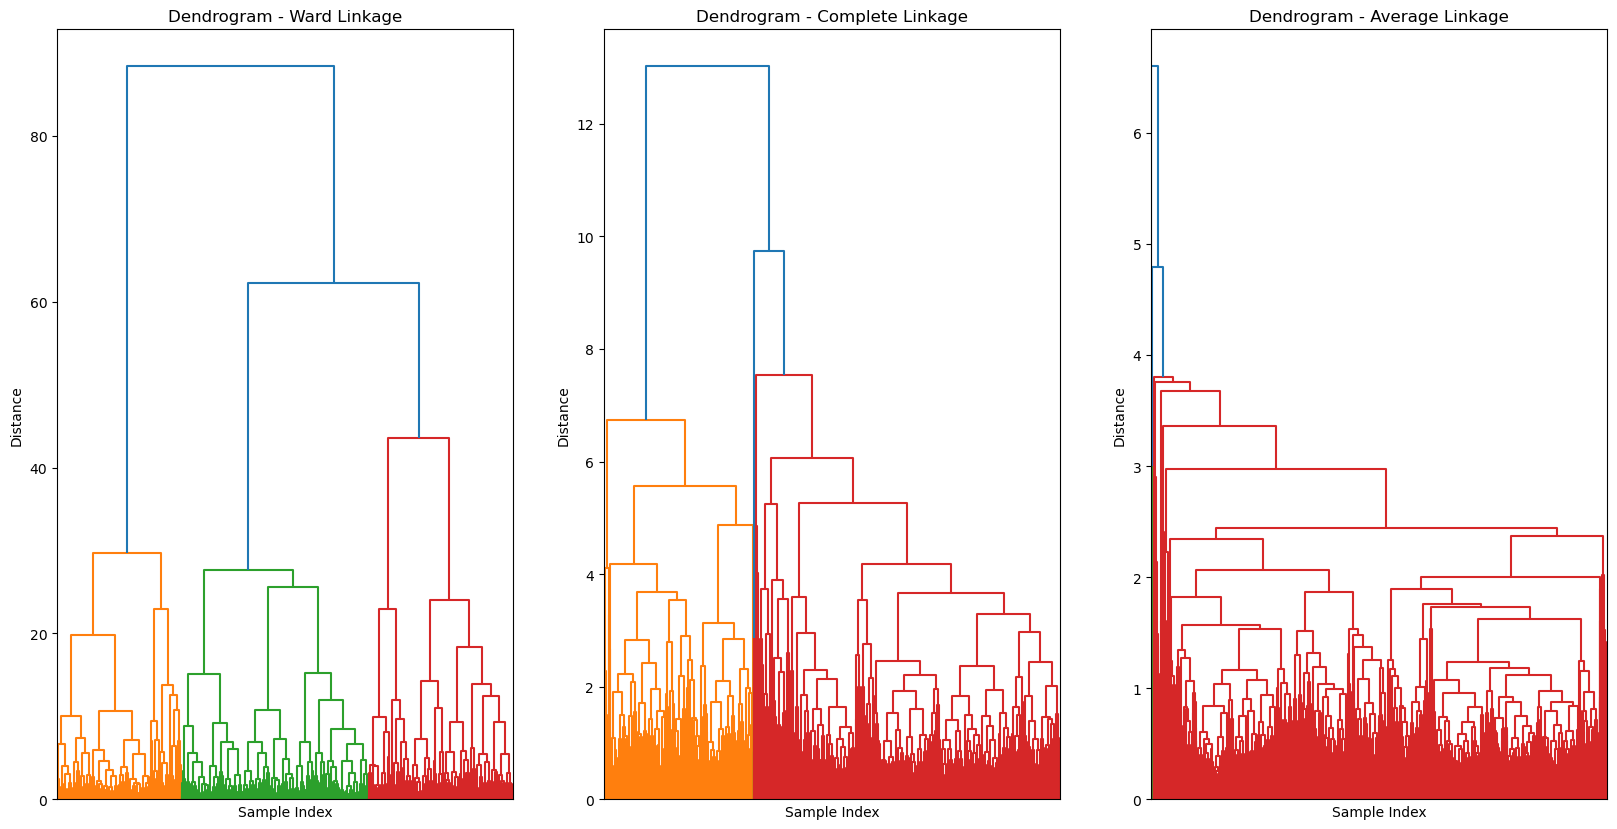

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for idx, method in enumerate(linkage_methods):
    dendrogram(linkage_results[method], ax=axes[idx], no_labels=True)
    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('Distance')
plt.show()

# ****Compare both algorithms using Silhouette, Davies-Bouldin, Calinski-Harabasz, cluster balance, and business interpretability.****

In [53]:
hierarchical_labels = fcluster(linkage_results['ward'], 4, criterion='maxclust') - 1
kmeans_labels = CustomerData["Cluster4"].values

In [59]:
print('Silhouette Score')
kmeans_silhouette = silhouette_score(CustomerData[Features], kmeans_labels)
hierarchical_silhouette = silhouette_score(CustomerData[Features], hierarchical_labels)
print(f'KMeans Silhouette Score: {kmeans_silhouette:.3f}')
print(f'Hierarchical Silhouette Score: {hierarchical_silhouette:.3f}')

Silhouette Score
KMeans Silhouette Score: 0.263
Hierarchical Silhouette Score: 0.246


In [60]:
print('Davies-Bouldin Index')
kmeans_db = davies_bouldin_score(CustomerData[Features], kmeans_labels)
hierarchical_db = davies_bouldin_score(CustomerData[Features], hierarchical_labels)
print(f'KMeans Davies-Bouldin Index: {kmeans_db:.3f}')
print(f'Hierarchical Davies-Bouldin Index: {hierarchical_db:.3f}')

Davies-Bouldin Index
KMeans Davies-Bouldin Index: 1.191
Hierarchical Davies-Bouldin Index: 1.235


In [61]:
print('Calinski-Harabasz Score')
kmeans_ch = calinski_harabasz_score(CustomerData[Features], kmeans_labels)
hierarchical_ch = calinski_harabasz_score(CustomerData[Features], hierarchical_labels)
print(f'KMeans Calinski-Harabasz Score: {kmeans_ch:.3f}')
print(f'Hierarchical Calinski-Harabasz Score: {hierarchical_ch:.3f}')

Calinski-Harabasz Score
KMeans Calinski-Harabasz Score: 1986.669
Hierarchical Calinski-Harabasz Score: 1733.726


In [62]:
print('Cluster Balance')
kmeans_counts = pd.Series(kmeans_labels).value_counts().sort_index().values
hierarchical_counts = pd.Series(hierarchical_labels).value_counts().sort_index().values
kmeans_balance = kmeans_counts.std() / kmeans_counts.mean()
hierarchical_balance = hierarchical_counts.std() / hierarchical_counts.mean()
print(f'KMeans Cluster Balance: {kmeans_balance:.3f}')
print(f'Hierarchical Cluster Balance: {hierarchical_balance:.3f}')

Cluster Balance
KMeans Cluster Balance: 0.354
Hierarchical Cluster Balance: 0.454


In [64]:
print("Summary Comparison Table:")

comparison_df = pd.DataFrame({
    'Metric': [
        'Silhouette Score',
        'Davies-Bouldin',
        'Calinski-Harabasz',
        'Balance (CV)'
    ],
    'K-Means': [
        f"{kmeans_silhouette:.4f}",
        f"{kmeans_db:.4f}",
        f"{kmeans_ch:.2f}",
        f"{kmeans_balance:.4f}"
    ],
    'Hierarchical': [
        f"{hierarchical_silhouette:.4f}",
        f"{hierarchical_db:.4f}",
        f"{hierarchical_ch:.2f}",
        f"{hierarchical_balance:.4f}"
    ],
    'Better': [
        'K-Means' if kmeans_silhouette > hierarchical_silhouette else 'Hierarchical',
        'Hierarchical' if hierarchical_db < kmeans_db else 'K-Means',
        'K-Means' if kmeans_ch > hierarchical_ch else 'Hierarchical',
        'K-Means' if kmeans_balance < hierarchical_balance else 'Hierarchical'
    ],
    'Direction': ['↑ Higher', '↓ Lower', '↑ Higher', '↓ Lower']
})
print(comparison_df.to_string(index=False))

Summary Comparison Table:
           Metric K-Means Hierarchical  Better Direction
 Silhouette Score  0.2630       0.2457 K-Means  ↑ Higher
   Davies-Bouldin  1.1915       1.2348 K-Means   ↓ Lower
Calinski-Harabasz 1986.67      1733.73 K-Means  ↑ Higher
     Balance (CV)  0.3543       0.4541 K-Means   ↓ Lower


In [70]:
print("Business Interpretability & Recommendations:")

print("\nK-Means Clustering:")
print("Advantages:")
print("  - Faster computation time")
print("  - Easier to interpret and implement")
print("  - Clear centroid-based segments")
print("  - Deterministic results with fixed random seed")
print("Disadvantages:")
print("  - Sensitive to initialization (local optima)")
print("  - Requires specifying k in advance")
print("  - May not work well with non-convex clusters")

print("\nHierarchical Clustering:")
print("Advantages:")
print("  - Dendrograms show complete merging process")
print("  - Flexible: multiple cut-off options possible")
print("  - Better for understanding cluster relationships")
print("  - No need to specify cluster count beforehand")
print("Disadvantages:")
print("  - Slower for large datasets (O(n²) complexity)")
print("  - Cannot undo previous merges (greedy approach)")
print("  - Sensitive to linkage method choice")

Business Interpretability & Recommendations:

K-Means Clustering:
Advantages:
  - Faster computation time
  - Easier to interpret and implement
  - Clear centroid-based segments
  - Deterministic results with fixed random seed
Disadvantages:
  - Sensitive to initialization (local optima)
  - Requires specifying k in advance
  - May not work well with non-convex clusters

Hierarchical Clustering:
Advantages:
  - Dendrograms show complete merging process
  - Flexible: multiple cut-off options possible
  - Better for understanding cluster relationships
  - No need to specify cluster count beforehand
Disadvantages:
  - Slower for large datasets (O(n²) complexity)
  - Cannot undo previous merges (greedy approach)
  - Sensitive to linkage method choice


In [72]:
kmeans_wins = sum([
    kmeans_silhouette > hierarchical_silhouette,
    kmeans_db < hierarchical_db,
    kmeans_ch > hierarchical_ch,
    kmeans_balance < hierarchical_balance
])
hierarchical_wins = 4 - kmeans_wins
print(f"\nMetrics Won:")
print(f"  K-Means:       {kmeans_wins}/4")
print(f"  Hierarchical:  {hierarchical_wins}/4")

if kmeans_wins >= 3:
    recommended = "K-Means Algorithm"
    reason = "K-Means performs better on most metrics and is computationally efficient."
elif hierarchical_wins >= 3:
    recommended = "Hierarchical Algorithm"
    reason = "Hierarchical Clustering provides better cluster relationships and flexibility."
else:
    recommended = "EITHER (with caveats)"
    reason = "Both algorithms show comparable performance. Choose based on business priorities."
print(f"\nRecommended Algorithm: {recommended}")
print(f"Reason: {reason}")


Metrics Won:
  K-Means:       4/4
  Hierarchical:  0/4

Recommended Algorithm: K-Means Algorithm
Reason: K-Means performs better on most metrics and is computationally efficient.


# ****Visualize final clusters in two dimensions using PCA and assign meaningful business names to every segment.****

In [74]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(CustomerData[Features])
pca_df = pd.DataFrame({
    'PC1': pca_features[:, 0],
    'PC2': pca_features[:, 1],
    'Cluster': CustomerData['Cluster4'].values
})
explained_variance = pca.explained_variance_ratio_
print('PCA Analysis:')
print(f"\nExplained Variance by Component:")
print(f"  PC1: {explained_variance[0]:.2%}")
print(f"  PC2: {explained_variance[1]:.2%}")
print(f"  Total: {sum(explained_variance):.2%}")

PCA Analysis:

Explained Variance by Component:
  PC1: 58.54%
  PC2: 22.42%
  Total: 80.96%


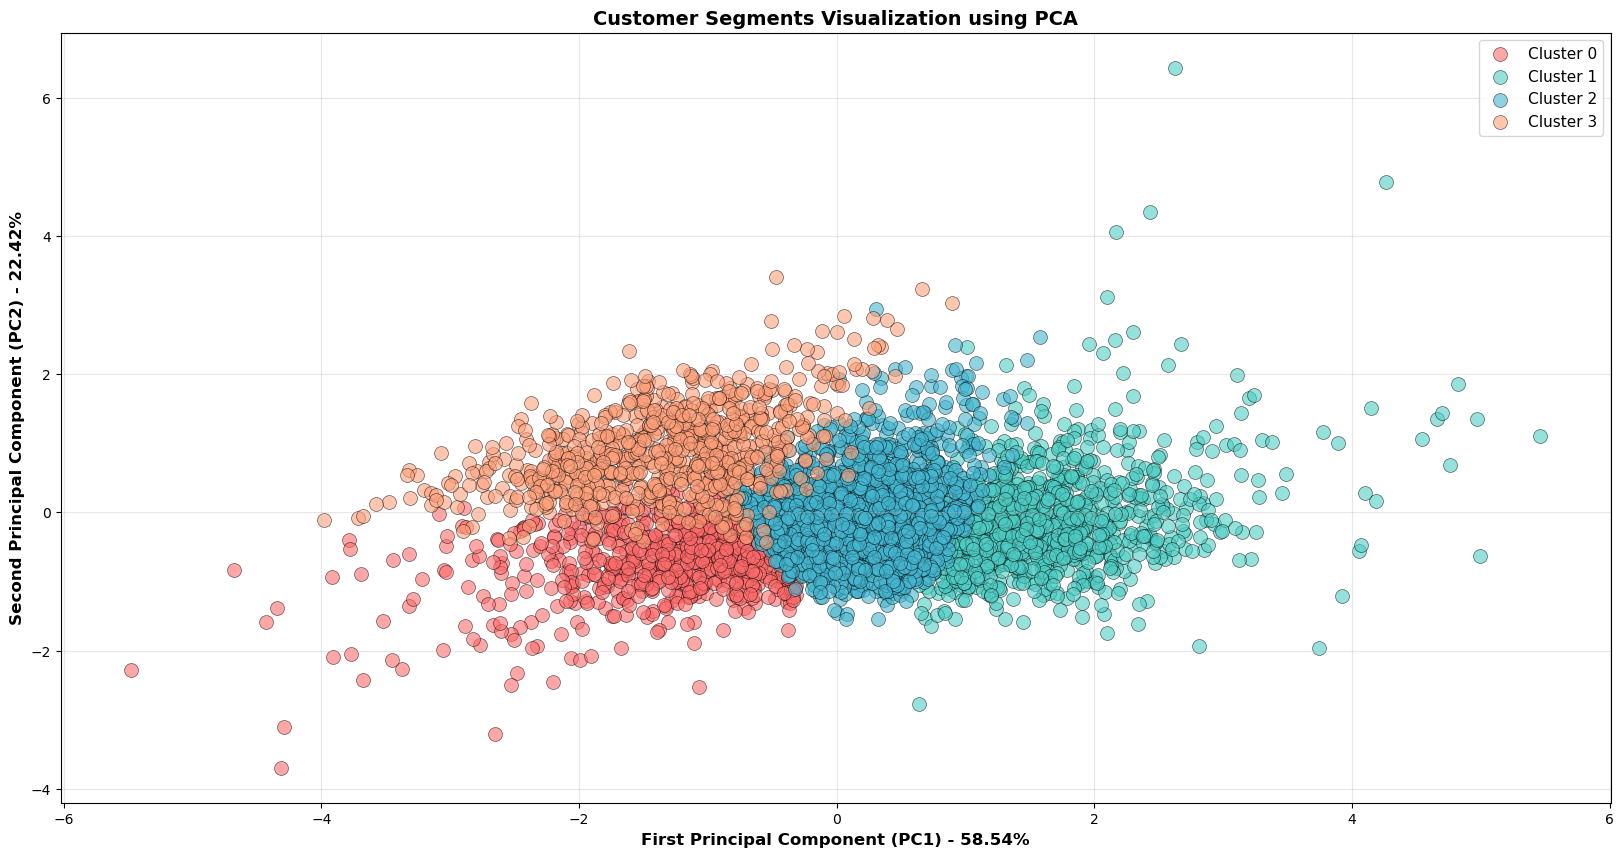

In [75]:
plt.figure(figsize=(20, 10))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
cluster_names_temp = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']
for cluster in range(4):
    mask = pca_df['Cluster'] == cluster
    plt.scatter(
        pca_df[mask]['PC1'], 
        pca_df[mask]['PC2'],
        c=colors[cluster],
        label=cluster_names_temp[cluster],
        s=100,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )
plt.xlabel(f'First Principal Component (PC1) - {explained_variance[0]:.2%}', fontsize=12, fontweight='bold')
plt.ylabel(f'Second Principal Component (PC2) - {explained_variance[1]:.2%}', fontsize=12, fontweight='bold')
plt.title('Customer Segments Visualization using PCA', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [78]:
print('PCA Cluster Characteristics:')
original_customer_data = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (Snapshot_Date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})
original_customer_data.columns = ["Recency", "Frequency", "Monetary"]
original_customer_data = original_customer_data.reset_index()
original_customer_data["AverageOrderValue"] = original_customer_data["Monetary"] / original_customer_data["Frequency"]
UniqueProducts_temp = df.groupby("CustomerID")["StockCode"].nunique().reset_index(name="UniqueProducts")
original_customer_data = original_customer_data.merge(UniqueProducts_temp, on='CustomerID', how="left")
original_customer_data['Cluster4'] = CustomerData['Cluster4'].values
for cluster in range(4):
    cluster_data = original_customer_data[original_customer_data['Cluster4'] == cluster]
    print(f"\nCluster {cluster} - Statistics:")
    print(f"  Size: {len(cluster_data)} customers ({len(cluster_data)/len(original_customer_data)*100:.1f}%)")
    print(f"  Recency (days):           Mean: {cluster_data['Recency'].mean():.1f}, Median: {cluster_data['Recency'].median():.1f}")
    print(f"  Frequency (purchases):    Mean: {cluster_data['Frequency'].mean():.1f}, Median: {cluster_data['Frequency'].median():.1f}")
    print(f"  Monetary (total spend):   Mean: {cluster_data['Monetary'].mean():.2f}, Median: {cluster_data['Monetary'].median():.2f}")
    print(f"  Avg Order Value:          Mean: {cluster_data['AverageOrderValue'].mean():.2f}, Median: {cluster_data['AverageOrderValue'].median():.2f}")
    print(f"  Unique Products:          Mean: {cluster_data['UniqueProducts'].mean():.1f}, Median: {cluster_data['UniqueProducts'].median():.1f}")

PCA Cluster Characteristics:

Cluster 0 - Statistics:
  Size: 760 customers (17.5%)
  Recency (days):           Mean: 77.1, Median: 58.5
  Frequency (purchases):    Mean: 1.7, Median: 1.0
  Monetary (total spend):   Mean: 214.26, Median: 183.97
  Avg Order Value:          Mean: 136.05, Median: 127.48
  Unique Products:          Mean: 14.7, Median: 11.0

Cluster 1 - Statistics:
  Size: 1068 customers (24.6%)
  Recency (days):           Mean: 28.4, Median: 16.0
  Frequency (purchases):    Mean: 10.8, Median: 8.0
  Monetary (total spend):   Mean: 6479.02, Median: 3020.86
  Avg Order Value:          Mean: 751.64, Median: 414.80
  Unique Products:          Mean: 147.3, Median: 115.0

Cluster 2 - Statistics:
  Size: 1717 customers (39.6%)
  Recency (days):           Mean: 57.2, Median: 44.0
  Frequency (purchases):    Mean: 2.7, Median: 2.0
  Monetary (total spend):   Mean: 873.45, Median: 752.60
  Avg Order Value:          Mean: 388.32, Median: 320.56
  Unique Products:          Mean: 47.6,

In [80]:
segment_names = {}
segment_strategy = {}
for cluster in range(4):
    cluster_data = original_customer_data[original_customer_data['Cluster4'] == cluster]
    recency = cluster_data['Recency'].median()
    frequency = cluster_data['Frequency'].median()
    monetary = cluster_data['Monetary'].median()
    avg_order = cluster_data['AverageOrderValue'].median()
    size = len(cluster_data)
    if recency < 60 and frequency > 30 and monetary > 1000:
        segment_names[cluster] = "VIP/Champions"
        segment_strategy[cluster] = "High-value, loyal customers. Personalized service, exclusive offers, VIP programs."
    elif recency < 120 and frequency > 15 and monetary > 500:
        segment_names[cluster] = "Loyal Customers"
        segment_strategy[cluster] = "Regular buyers with consistent value. Rewards programs, cross-sell opportunities."
    elif recency > 180 and frequency < 10 and monetary < 300:
        segment_names[cluster] = "At-Risk/Churned"
        segment_strategy[cluster] = "Inactive customers. Re-engagement campaigns, win-back offers, special incentives."
    elif frequency < 5 and recency < 60:
        segment_names[cluster] = "New Customers"
        segment_strategy[cluster] = "Recent first-time or occasional buyers. Onboarding, education, trust-building."
    else:
        segment_names[cluster] = "Potential/Developing"
        segment_strategy[cluster] = "Mid-tier customers with growth potential. Targeted promotions, upselling."

In [81]:
print("Customer Segmentation Summary:")
segment_summary = []
for cluster in range(4):
    cluster_data = original_customer_data[original_customer_data['Cluster4'] == cluster]
    segment_summary.append({
        'Segment': segment_names[cluster],
        'Cluster ID': cluster,
        'Size': f"{len(cluster_data)} ({len(cluster_data)/len(original_customer_data)*100:.1f}%)",
        'Avg Recency (days)': f"{cluster_data['Recency'].mean():.0f}",
        'Avg Frequency': f"{cluster_data['Frequency'].mean():.0f}",
        'Avg Spend (£)': f"{cluster_data['Monetary'].mean():.0f}",
        'Avg Order Value (£)': f"{cluster_data['AverageOrderValue'].mean():.2f}"
    })

segment_summary_df = pd.DataFrame(segment_summary)
print(segment_summary_df.to_string(index=False))

Customer Segmentation Summary:
             Segment  Cluster ID         Size Avg Recency (days) Avg Frequency Avg Spend (£) Avg Order Value (£)
       New Customers           0  760 (17.5%)                 77             2           214              136.05
Potential/Developing           1 1068 (24.6%)                 28            11          6479              751.64
       New Customers           2 1717 (39.6%)                 57             3           873              388.32
Potential/Developing           3  793 (18.3%)                270             1           385              301.20


In [82]:
print('Recommended Marketing Strategies for Each Segment:')
for cluster in range(4):
    cluster_data = original_customer_data[original_customer_data['Cluster4'] == cluster]
    print(f"\n{segment_names[cluster].upper()} - Cluster {cluster}")
    print(f"  Size: {len(cluster_data)} customers")
    print(f"  Strategy: {segment_strategy[cluster]}")
    print(f"  Actions:")
    if "VIP" in segment_names[cluster]:
        print(f"    • Dedicated account manager")
        print(f"    • Exclusive early access to new products")
        print(f"    • Personalized recommendations based on purchase history")
        print(f"    • Special discounts and loyalty rewards")
        print(f"    • Quarterly business reviews")
    elif "Loyal" in segment_names[cluster]:
        print(f"    • Tiered loyalty program")
        print(f"    • Regular promotional emails")
        print(f"    • Cross-sell and upsell recommendations")
        print(f"    • Referral incentives")
        print(f"    • Birthday/anniversary offers")
    elif "At-Risk" in segment_names[cluster]:
        print(f"    • Re-engagement email campaigns")
        print(f"    • Limited-time win-back offers (20-30% discount)")
        print(f"    • Survey to understand reasons for inactivity")
        print(f"    • Showcase new products and improvements")
        print(f"    • Consider removing from future campaigns if no response")
    elif "New" in segment_names[cluster]:
        print(f"    • Welcome email series")
        print(f"    • First purchase follow-up")
        print(f"    • Educational content about products")
        print(f"    • New customer incentives (10-15% discount)")
        print(f"    • Encourage reviews and feedback")
    else:
        print(f"    • Targeted growth campaigns")
        print(f"    • Product bundle offers")
        print(f"    • Category-specific promotions")
        print(f"    • Frequency incentives")
        print(f"    • Monitor for upgrade to higher tier")

Recommended Marketing Strategies for Each Segment:

NEW CUSTOMERS - Cluster 0
  Size: 760 customers
  Strategy: Recent first-time or occasional buyers. Onboarding, education, trust-building.
  Actions:
    • Welcome email series
    • First purchase follow-up
    • Educational content about products
    • New customer incentives (10-15% discount)
    • Encourage reviews and feedback

POTENTIAL/DEVELOPING - Cluster 1
  Size: 1068 customers
  Strategy: Mid-tier customers with growth potential. Targeted promotions, upselling.
  Actions:
    • Targeted growth campaigns
    • Product bundle offers
    • Category-specific promotions
    • Frequency incentives
    • Monitor for upgrade to higher tier

NEW CUSTOMERS - Cluster 2
  Size: 1717 customers
  Strategy: Recent first-time or occasional buyers. Onboarding, education, trust-building.
  Actions:
    • Welcome email series
    • First purchase follow-up
    • Educational content about products
    • New customer incentives (10-15% discount

In [84]:
segment_names_list = [segment_names[cluster] for cluster in CustomerData['Cluster4']]
CustomerData['SegmentName'] = segment_names_list
print("Sample Data with Segment Names:")
print(CustomerData[['CustomerID', 'Cluster4', 'SegmentName', 'Recency', 'Frequency', 'Monetary']].head(10))

Sample Data with Segment Names:
   CustomerID  Cluster4           SegmentName   Recency  Frequency  Monetary
0     12346.0         1  Potential/Developing  2.217742  -0.369070  2.813866
1     12347.0         1  Potential/Developing -0.395161   0.892789  1.103830
2     12348.0         2         New Customers  0.193548   0.464974  0.585572
3     12349.0         2         New Customers -0.258065  -0.369070  0.572343
4     12350.0         3  Potential/Developing  2.088710  -0.369070 -0.409759
5     12352.0         1  Potential/Developing -0.120968   1.000000  0.782532
6     12353.0         0         New Customers  1.233871  -0.369070 -1.189501
7     12354.0         2         New Customers  1.459677  -0.369070  0.283591
8     12355.0         3  Potential/Developing  1.314516  -0.369070 -0.222000
9     12356.0         1  Potential/Developing -0.225806   0.261860  0.850663


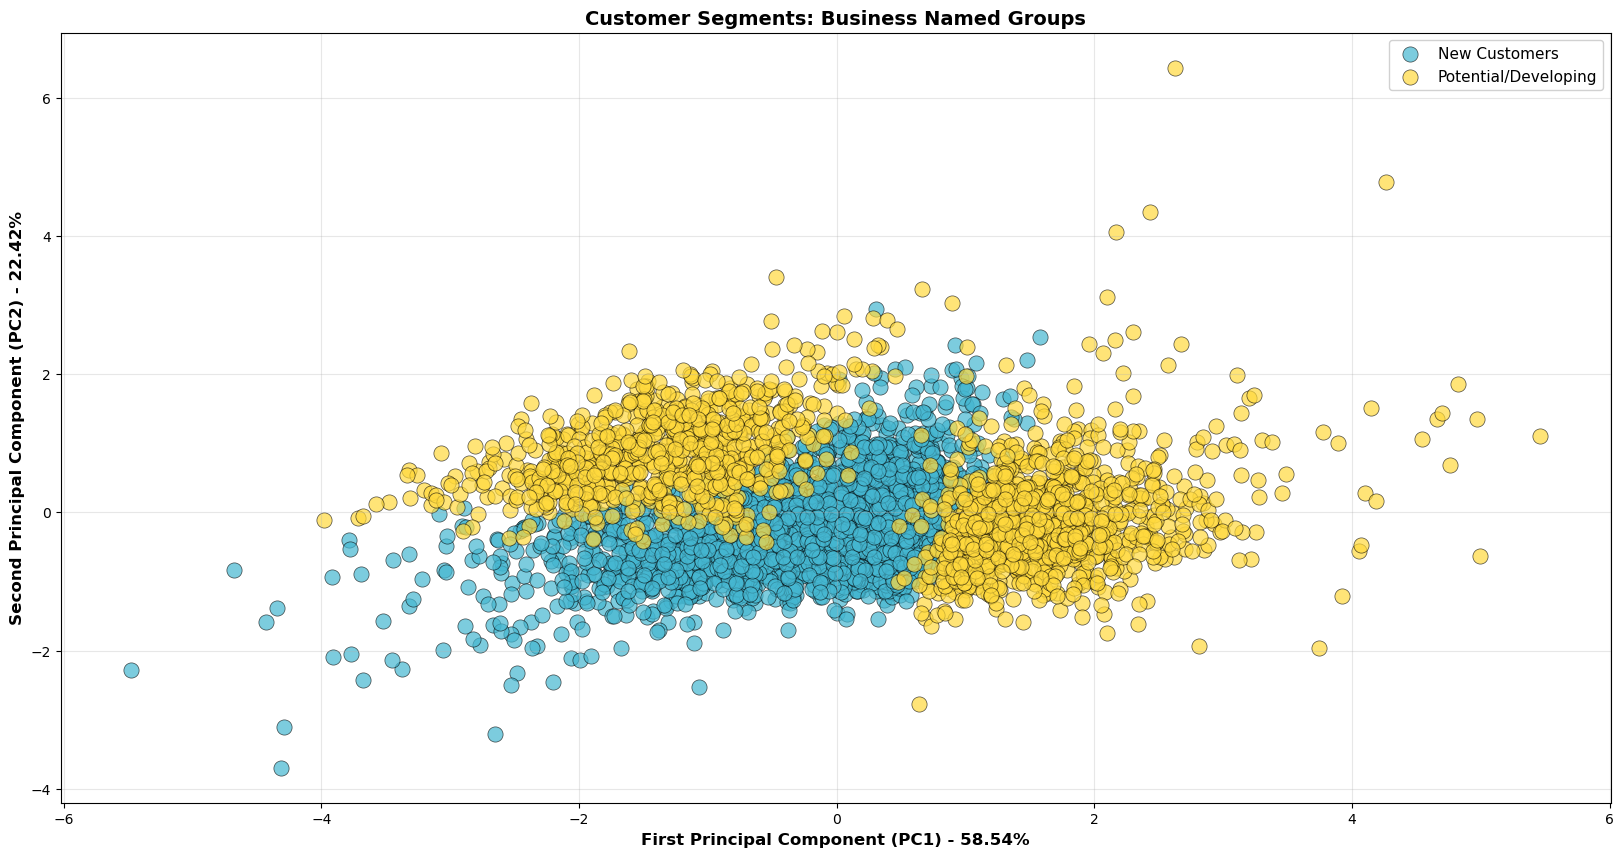

In [85]:
plt.figure(figsize=(20, 10))
segment_colors = {
    "VIP/Champions": '#FF6B6B',
    "Loyal Customers": '#4ECDC4',
    "At-Risk/Churned": '#FFA07A',
    "New Customers": '#45B7D1',
    "Potential/Developing": '#FFD93D'
}
for segment_name, color in segment_colors.items():
    mask = CustomerData['SegmentName'] == segment_name
    if mask.any():
        plt.scatter(
            pca_df[mask]['PC1'],
            pca_df[mask]['PC2'],
            c=color,
            label=segment_name,
            s=120,
            alpha=0.7,
            edgecolors='black',
            linewidth=0.5
        )
plt.xlabel(f'First Principal Component (PC1) - {explained_variance[0]:.2%}', fontsize=12, fontweight='bold')
plt.ylabel(f'Second Principal Component (PC2) - {explained_variance[1]:.2%}', fontsize=12, fontweight='bold')
plt.title('Customer Segments: Business Named Groups', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.show()

# ****Build a small Streamlit dashboard that accepts customer data, displays segments, and presents retention recommendations.****